Text(0, 0.5, 'Weight (kg)')

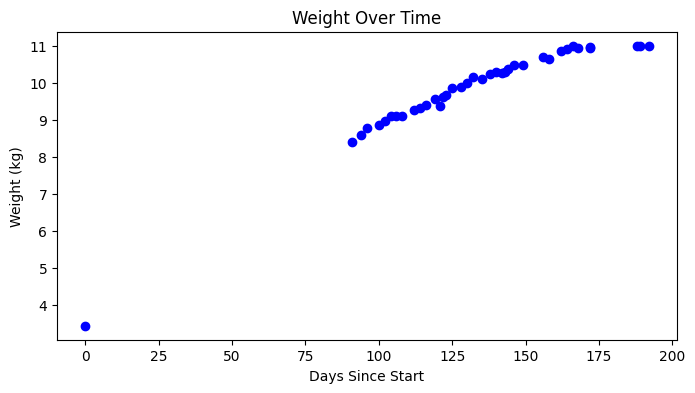

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import numpy as np


data=[
    ['2025-10-02', 3.44],
    ['2026-01-01', 8.41], 
    ['2026-01-04', 8.6],
    ['2026-01-06', 8.78], 
    ['2026-01-10', 8.87], 
    ['2026-01-12', 8.97],
    ['2026-01-14', 9.1],
    ['2026-01-16', 9.11],
    ['2026-01-18', 9.11],
    ['2026-01-22', 9.26],
    ['2026-01-24', 9.33],
    ['2026-01-26', 9.40],
    ['2026-01-29', 9.57],
    ['2026-01-31', 9.38],
    ['2026-02-01', 9.62],
    ['2026-02-02', 9.66],
    ['2026-02-04', 9.85],
    ['2026-02-07', 9.89],
    ['2026-02-09', 10],
    ['2026-02-11', 10.15],
    ['2026-02-14', 10.09],
    ['2026-02-17', 10.23],
    ['2026-02-19', 10.29],
    ['2026-02-21', 10.27],
    ['2026-02-22', 10.28],
    ['2026-02-23', 10.37],
    ['2026-02-25', 10.49],
    ['2026-02-28', 10.47],
    ['2026-03-07', 10.69],
    ['2026-03-09', 10.63],
    ['2026-03-13', 10.87],
    ['2026-03-15', 10.90],
    ['2026-03-17', 10.98],
    ['2026-03-19', 10.93],
    ['2026-03-23', 10.94],
    ['2026-03-23', 10.96],
    ['2026-04-08', 10.99],
    ['2026-04-09', 11],
    ['2026-04-12', 10.99],
    ]

data=pd.DataFrame(data, columns=['Date', 'weight'])
data['Date'] = pd.to_datetime(data['Date'])
data['Date'] = data['Date']-data['Date'].min()
data['Date'] = data['Date'].dt.days

X=data['Date'].values.reshape(-1,1)
y=data['weight'].values.reshape(-1,1)

plt.figure(figsize=(8,4))
plt.scatter(X, y, color='blue', label='Data Points')
plt.title('Weight Over Time')
plt.xlabel('Days Since Start')
plt.ylabel('Weight (kg)')

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(y.flatten(), trend='additive', seasonal=None)
fit = model.fit()

forecast = fit.forecast(365)  # 5 step 예측

In [13]:
newx=[X.max()+i+1 for i in range(forecast.shape[0])] 


Text(0, 0.5, 'Weight (kg)')

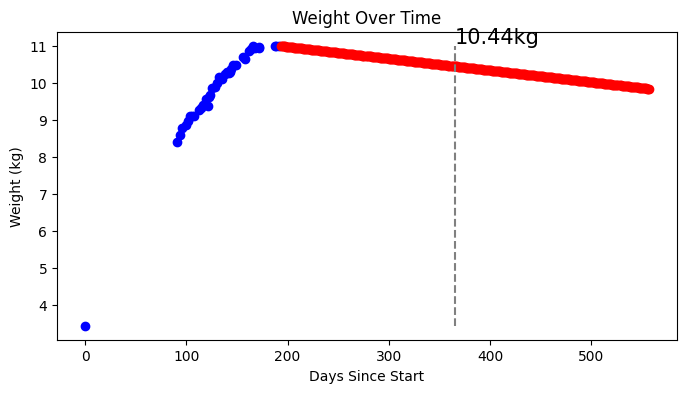

In [14]:
plt.figure(figsize=(8,4))
plt.scatter(X, y, color='blue', label='Data Points')
plt.scatter(newx, forecast, color='red', label='Forecast')
plt.vlines(365, ymin=y.min(), ymax=forecast.max(), color='gray', linestyle='--', label='dol')
plt.text(365, forecast[365-X.max()]+0.5, str(round(forecast[365-X.max()],2))+'kg', ha='left', va='bottom', fontsize=15, color='black')
plt.title('Weight Over Time')
plt.xlabel('Days Since Start')
plt.ylabel('Weight (kg)')

In [14]:
from scipy.optimize import curve_fit

def exp_model(x, a, b, c,d):
    return a * x**0.5 + b * np.exp(x)  + c * x +d  

params, _ = curve_fit(exp_model, X.flatten(), y.flatten())

Text(0, 0.5, 'Weight (kg)')

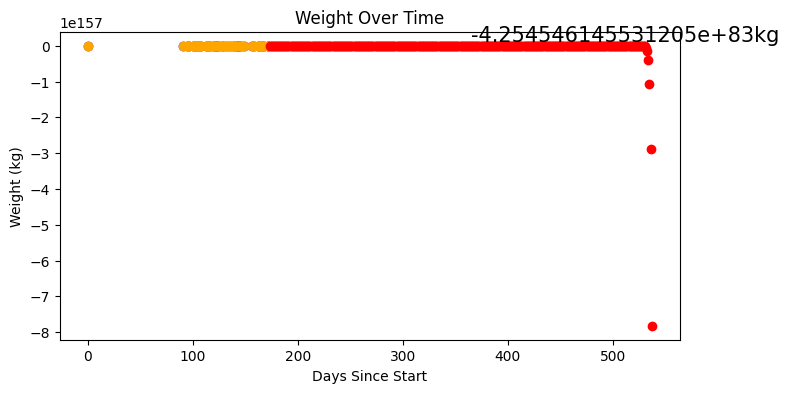

In [15]:
newx=np.array(newx)
plt.figure(figsize=(8,4))
plt.scatter(X, y, color='blue', label='Data Points')
plt.scatter(X, exp_model(X, *params), color='orange', label='Pred')
plt.scatter(newx, exp_model(newx.astype(float), *params), color='red', label='Forecast')
plt.vlines(365, ymin=y.min(), ymax=exp_model(newx.astype(float), *params).max(), color='gray', linestyle='--', label='dol')
plt.text(365, exp_model(newx.astype(float), *params)[365-X.max()]+0.5, str(round(exp_model(newx.astype(float), *params)[365-X.max()],2))+'kg', ha='left', va='bottom', fontsize=15, color='black')
plt.title('Weight Over Time')
plt.xlabel('Days Since Start')
plt.ylabel('Weight (kg)')

Text(0, 0.5, 'Weight (kg)')

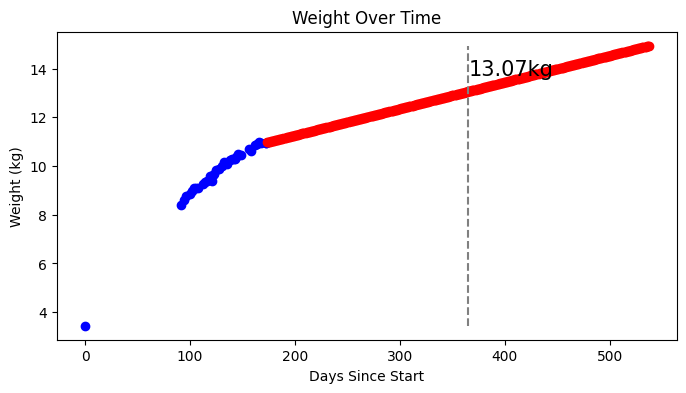

In [18]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(y.flatten(), trend='additive')
fit = model.fit()

forecast = fit.forecast(365)  # 5 step 예측
newx=[X.max()+i+1 for i in range(forecast.shape[0])] 
plt.figure(figsize=(8,4))
plt.scatter(X, y, color='blue', label='Data Points')
plt.scatter(newx, forecast, color='red', label='Forecast')
plt.vlines(365, ymin=y.min(), ymax=forecast.max(), color='gray', linestyle='--', label='dol')
plt.text(365, forecast[365-X.max()]+0.5, str(round(forecast[365-X.max()],2))+'kg', ha='left', va='bottom', fontsize=15, color='black')
plt.title('Weight Over Time')
plt.xlabel('Days Since Start')
plt.ylabel('Weight (kg)')